

# Лабораторная работа №3

## Тема: **"Апериодические сигналы"**

---

**Работу выполнил:**  
Студент группы **5130901/20103**  
**Лучер Дмитрий Владимирович**

---

In [1]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

from thinkdsp import Chirp, PI2, normalize, unbias, read_wave
import numpy as np

## Упражнение 3.1

В файле **chap03.ipynb** рассматриваются элементы библиотеки **`ThinkDSP`**, такие как класс **`Chirp`**, функция **`hamming`** для вычисления окна Хэмминга, а также работа со спектрограммами.

Ниже приведён пример, аналогичный представленному в **chap03.ipynb**, но для подавления спектральной утечки используется окно Бартлетта.

Создадим сегмент с дробным числом периодов. На графике будет заметна выраженная утечка спектра.

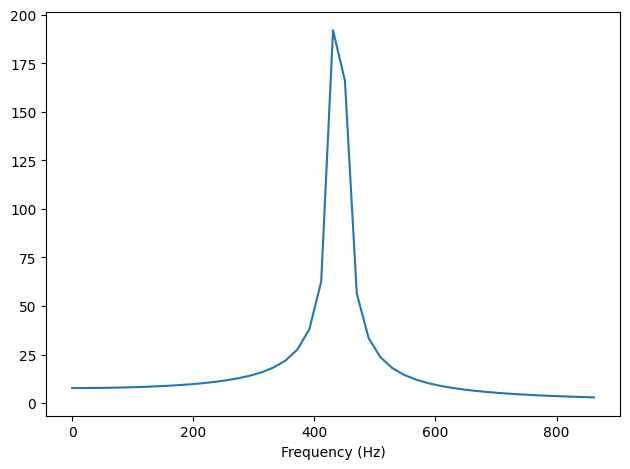

In [6]:
import numpy as np
from thinkdsp import SinSignal, decorate
signal = SinSignal(freq=440)
duration = signal.period * 22.45
wave = signal.make_wave(duration)
spectrum = wave.make_spectrum()
spectrum.plot(high=880)
decorate(xlabel='Frequency (Hz)')

Теперь вместо окна Хэмминга применим к сигналу окно Бартлетта. Результат отличается от предыдущего примера: утечка уменьшилась — по краям от основного пика спектра стало заметно ровнее, хотя полностью она не исчезла.

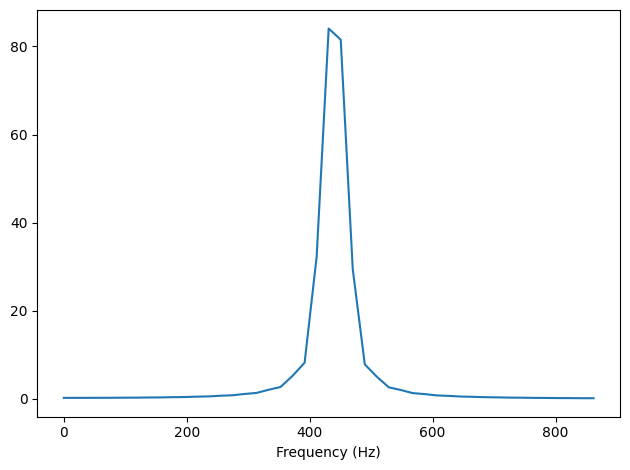

In [8]:
wave.ys *= np.bartlett(len(wave.ys))
spectrum = wave.make_spectrum()
spectrum.plot(high=880)

decorate(xlabel='Frequency (Hz)')

## Упражнение 3.2

Реализуем класс **`SawtoothChirp`**, наследующий от **`Chirp`**, и переопределим метод **`evaluate`** для генерации пилообразного сигнала с линейно изменяющейся частотой (возрастающей или убывающей).


In [9]:
class SawtoothChirp(Chirp):
    def evaluate(self, ts):
        freqs = np.linspace(self.start, self.end, len(ts))
        dts = np.diff(ts, prepend=0)
        dphis = PI2 * freqs * dts
        phases = np.cumsum(dphis)
        cycles = phases / PI2
        frac, _ = np.modf(cycles)
        ys =  normalize(unbias(frac), self.amp)
        return ys

Нарисуем эскиз спектрограммы полученного сигнала.

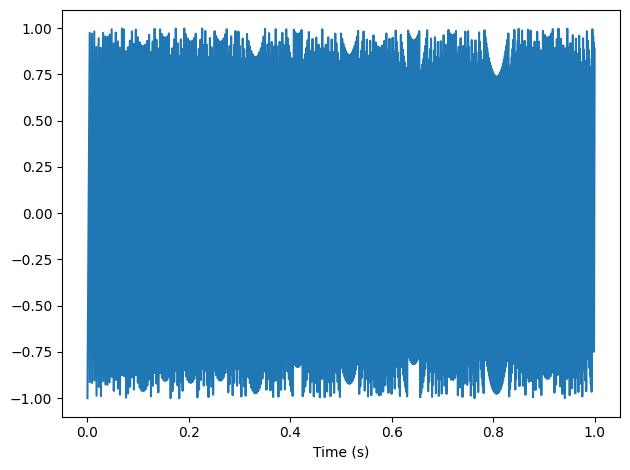

In [16]:
signal = SawtoothChirp(start=220, end=660)
wave = signal.make_wave(duration=1, framerate=4025)
wave.segment(start=0, duration=1).plot() 
decorate(xlabel='Time (s)')

Прослушаем полученный сигнал. На фоне слышны едва различимые биения.

In [17]:
wave.make_audio()

Выведем спектрограмму сигнала. На ней уже явно видны те самые биения.

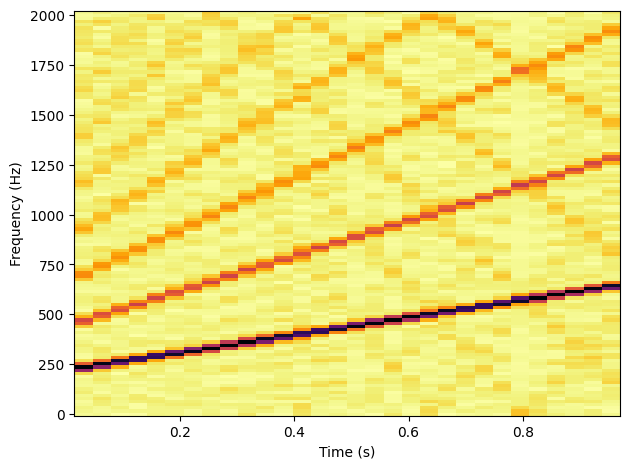

In [18]:
sp = wave.make_spectrogram(256)
sp.plot()
decorate(xlabel='Time (s)', ylabel='Frequency (Hz)')

## Упражнение 3.3

Создадим пилообразный чирп с линейным изменением частоты от 2500 Гц до 3000 Гц. На его основе сгенерируем сигнал длительностью 1 секунду с частотой дискретизации 20 кГц.

In [21]:
new_stchirp = SawtoothChirp(start=2500, end=3000)
new_stwave = new_stchirp.make_wave(duration=1, framerate=20000)
new_stwave.make_audio()

Получим `Spectrum` этого сигнала. 

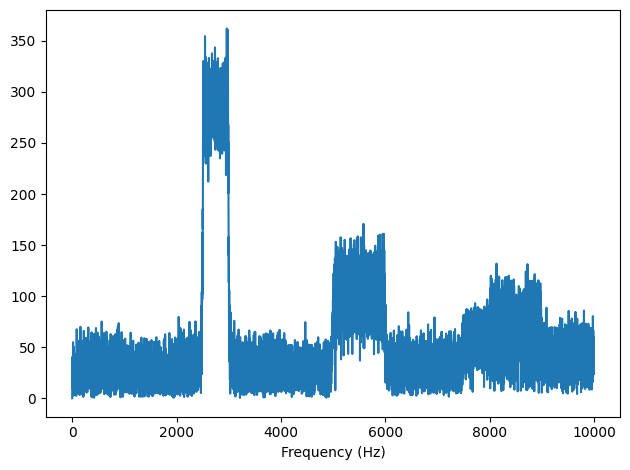

In [22]:
new_stwave.make_spectrum().plot()
decorate(xlabel='Frequency (Hz)')

## Упражнение 3.4

Рассмотрим начало композиции "Rhapsody in Blue", в котором присутствует глиссандо.

In [27]:
glissando_wave = read_wave(filename='./audio/rhapblue.wav')
glissando_wave.make_audio()

На спектрограмме отчетливо видно, как в первые 2.5 секунды частота плавно нарастает, что соответствует действительности.

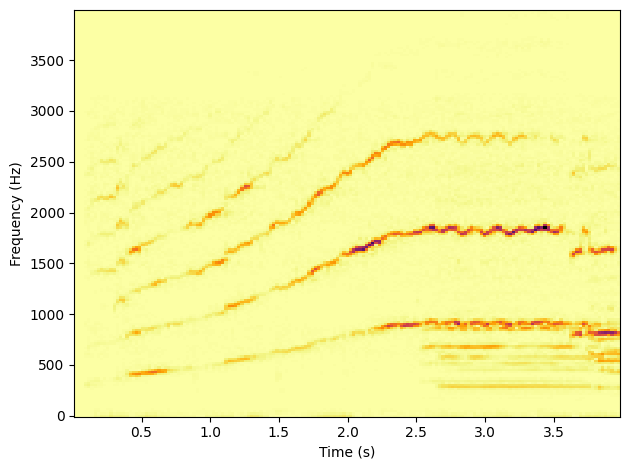

In [29]:
glissando_wave.segment(start=0, duration=4).make_spectrogram(512).plot(high=4000)
decorate(xlabel='Time (s)', ylabel='Frequency (Hz)')

## Упражнение 3.5

Если тромбонист исполняет глиссандо, плавно передвигая кулису с постоянной скоростью, частота изменяется во времени обратно пропорционально:  
$$
f(t) \propto \frac{1}{t}
$$

Создадим класс **`TromboneGliss`**, расширяющий **`Chirp`** и реализующий метод **`evaluate`** для моделирования такого изменения частоты.


In [30]:
class TromboneGliss(Chirp):
    def evaluate(self, ts):
        l1, l2 = 1.0 / self.start, 1.0 / self.end
        lengths = np.linspace(l1, l2, len(ts))
        freqs = 1 / lengths
        
        dts = np.diff(ts, prepend=0)
        dphis = PI2 * freqs * dts
        phases = np.cumsum(dphis)
        ys = self.amp * np.cos(phases)
        return ys

Создадим сигнал, имитирующий глиссандо на тромбоне от ноты A3 (220 Гц) до F3 и обратно.  
Если сравнить его звучание с линейным и экспоненциальным чирпами, то оно будет восприниматься как нечто среднее между ними.


In [31]:
a3 = 220
f3 = 349
a3f3a3 = TromboneGliss(a3, f3).make_wave(duration=1) | TromboneGliss(f3, a3).make_wave(duration=1)
a3f3a3.make_audio()

Также построим спектрограмму полученного сигнала. На ней видно, как частота сигнала сначала увеличивается, а затем уменьшается. Изменение частоты имеет нелинейный характер, при этом скорость изменения частоты возрастает не так быстро, как в случае с экспоненциальным чирпом.

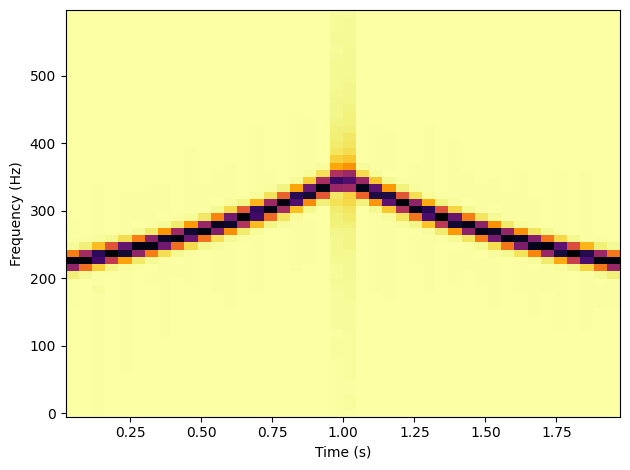

In [34]:
a3f3a3.make_spectrogram(1024).plot(high=600)
decorate(xlabel='Time (s)', ylabel='Frequency (Hz)')

## Упражнение 3.6

Из открытых источников взят аудиофайл, в котором различные люди произносят буквы.

In [40]:
vowels = read_wave(filename='./audio/vowels.wav')
vowels.make_audio()

Выведем спектрограммы для звуков.

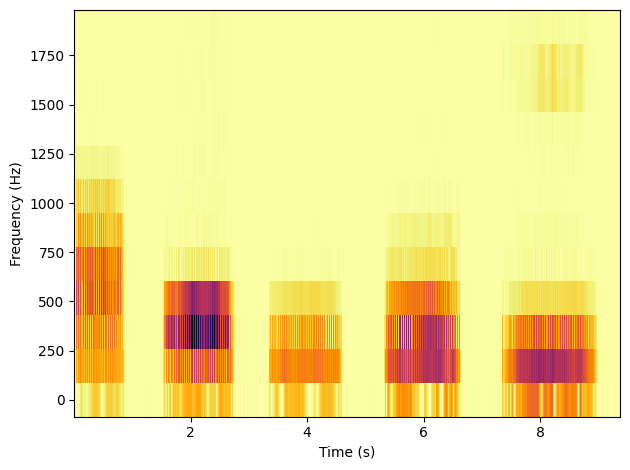

In [43]:
vowels.segment(start=0, duration=10).make_spectrogram(256).plot(high=2000)
decorate(xlabel='Time (s)', ylabel='Frequency (Hz)')

Из анализов спектрограмм различных гласных звуков, произнесённых разными людьми, видно, что они имеют схожие характеристики, несмотря на заметные различия в тембре и высоте голос. Каждый звук на спектрограмме имеет уникальную форму.

Эти особенности могут быть использованы для разработки технологий преобразования речи в текст, синтеза речи, создания голосовых помощников и других приложений.
